In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

In [2]:
df= pd.read_csv(r'C:\Users\alyah\VC\first_project\data\reddit_artist_posts.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124438 entries, 0 to 124437
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            124438 non-null  object 
 1   title         124438 non-null  object 
 2   selftext      69187 non-null   object 
 3   author        124278 non-null  object 
 4   created_utc   124438 non-null  float64
 5   score         124438 non-null  int64  
 6   num_comments  124438 non-null  int64  
 7   subreddit     124438 non-null  object 
 8   keyword       124438 non-null  object 
 9   source        124438 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 9.5+ MB


In [ ]:
df['created_at'] = pd.to_datetime(df['created_utc'], unit='s').dt.date
df.head(10)
# we made a new column with date only from created_utc timestamp

In [5]:
df.isnull().sum()

id                  0
title               0
selftext        55251
author            160
created_utc         0
score               0
num_comments        0
subreddit           0
keyword             0
source              0
created_at          0
dtype: int64

In [6]:
# Find rows where both title and selftext are null or empty
mask = (df['title'].isnull() | (df['title'].str.strip() == "")) & \
       (df['selftext'].isnull() | (df['selftext'].str.strip() == ""))

null_rows = df[mask]
print(null_rows)

# we got non rows where both title and selftext are null or empty
# this is good cuz latter we will combine both columns into one for our model training

Empty DataFrame
Columns: [id, title, selftext, author, created_utc, score, num_comments, subreddit, keyword, source, created_at]
Index: []


### before we combine our columns we first will manual clean and drop rows where it might contain data not related to pop music or our artists 

In [ ]:
df["keyword"].value_counts().head(20)

In [ ]:
df["subreddit"].value_counts().head(20)

In [ ]:
combo_counts = df.groupby(['subreddit', 'keyword']).size().reset_index(name='count')
print(combo_counts.sort_values('count', ascending=False).head(50))
# alot of keywords and subbreddits combiantions are irrelevant so we will clean them out next

In [29]:
# Keep only specific keywords in NoStupidQuestions, drop the rest
allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","eras tour","pop music","Grammy"
    ,
]

mask = ~((df['subreddit'] == "NoStupidQuestions") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]

# Keep only specific keywords in teenagers, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour","Grammy"
]

mask = ~((df['subreddit'] == "teenagers") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]

# Keep only specific keywords in Fauxmoi, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour",
    "tour","concert","American Music Awards",'Grammy'
]

mask = ~((df['subreddit'] == "Fauxmoi") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]


# Keep only specific keywords in entertainment, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour",
    "Billboard Hot 100","American Music Awards",'Grammy',"tour","concert"
]

mask = ~((df['subreddit'] == "entertainment") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]


# Keep only specific keywords in popculture, drop the rest

allowed_keywords = [
    
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour",
    "Billboard Hot 100","American Music Awards",'Grammy',"tour","concert"
]

mask = ~((df['subreddit'] == "popculture") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]



# Keep only specific keywords in popculturechat, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour",
    "Billboard Hot 100","American Music Awards",'Grammy',"tour","concert","bop"
]

mask = ~((df['subreddit'] == "popculturechat") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]




# Keep only specific keywords in spotify, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour",
    "Top 40","pop hits","bop"
]

mask = ~((df['subreddit'] == "spotify") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]



# Keep only specific keywords in Songwriters, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour"
]

mask = ~((df['subreddit'] == "Songwriters") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]



# Keep only specific keywords in musicians, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","eras tour","pop music"
]

mask = ~((df['subreddit'] == "musicians") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]



# Keep only specific keywords in WeAreTheMusicMakers, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","eras tour","pop music"
]

mask = ~((df['subreddit'] == "WeAreTheMusicMakers") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]


# Keep only specific keywords in YoutubeMusic, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour"
    
]

mask = ~((df['subreddit'] == "YoutubeMusic") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]



# Keep only specific keywords in musictheory, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour","pop hits"
    
]

mask = ~((df['subreddit'] == "musictheory") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]




# Keep only specific keywords in indieheads, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour","pop hits","Grammy"
    
    
]

mask = ~((df['subreddit'] == "indieheads") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]



# Keep only specific keywords in LetsTalkMusic, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour","pop hits","concert",
    "Grammy","Billboard Hot 100","American Music Awards"
    
]

mask = ~((df['subreddit'] == "LetsTalkMusic") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]


# Keep only specific keywords in newmusic, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour","pop hits"
    
]

mask = ~((df['subreddit'] == "newmusic") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]

# Keep only specific keywords in kpop, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour","pop hits",
    "grammy","Billboard Hot 100","American Music Awards","concert","tour",'bop'
    
]

mask = ~((df['subreddit'] == "kpop") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]

# Keep only specific keywords in Music, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour","pop hits",
    "grammy","Billboard Hot 100","American Music Awards","concert","tour",'bop'
    
]

mask = ~((df['subreddit'] == "Music") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]


# Keep only specific keywords in billboard, drop the rest

allowed_keywords = [
    "Taylor Swift", "Olivia Rodrigo", "Ariana Grande", 
    "Billie Eilish", "Sabrina Carpenter", "Tate McRae","pop music","eras tour","pop hits",
    "grammy","Billboard Hot 100","American Music Awards","concert","tour",'bop'
    
]

mask = ~((df['subreddit'] == "billboard") & (~df['keyword'].isin(allowed_keywords)))
df = df[mask]



In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49732 entries, 0 to 121614
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            49732 non-null  object 
 1   title         49732 non-null  object 
 2   selftext      24945 non-null  object 
 3   author        49635 non-null  object 
 4   created_utc   49732 non-null  float64
 5   score         49732 non-null  int64  
 6   num_comments  49732 non-null  int64  
 7   subreddit     49732 non-null  object 
 8   keyword       49732 non-null  object 
 9   source        49732 non-null  object 
 10  created_at    49732 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 4.6+ MB


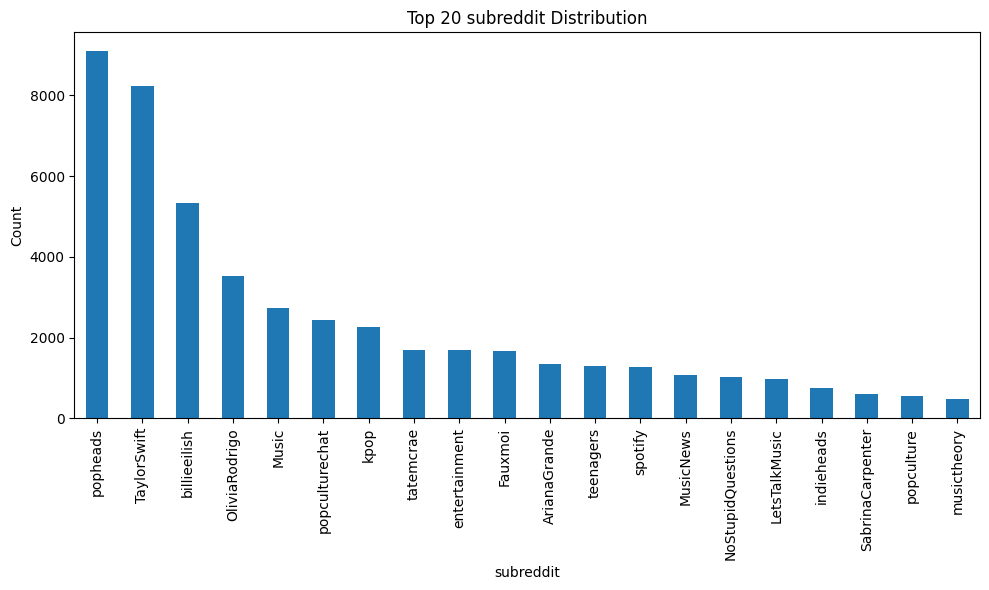

In [41]:
top_keywords = df['subreddit'].value_counts().head(20)

plt.figure(figsize=(10,6))
top_keywords.plot(kind='bar')
plt.title('Top 20 subreddit Distribution')
plt.xlabel('subreddit')
plt.ylabel('Count')
plt.xticks()
plt.tight_layout()
plt.show()

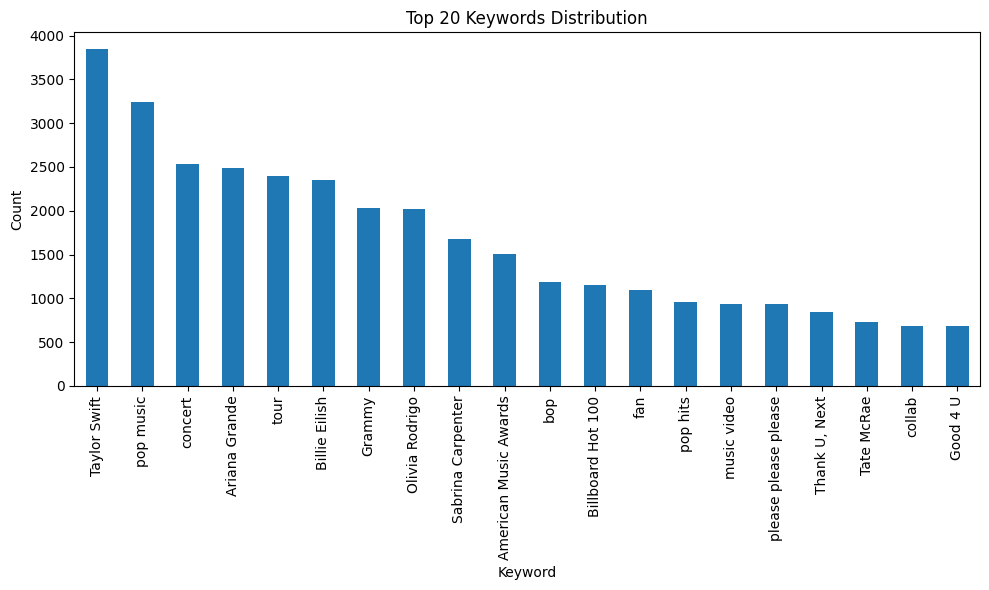

In [42]:
top_keywords = df['keyword'].value_counts().head(20)

plt.figure(figsize=(10,6))
top_keywords.plot(kind='bar')
plt.title('Top 20 Keywords Distribution')
plt.xlabel('Keyword')
plt.ylabel('Count')
plt.xticks()
plt.tight_layout()
plt.show()

In [43]:
combo_counts = df.groupby(['subreddit', 'keyword']).size().reset_index(name='count')
print(combo_counts.sort_values('count', ascending=False).head(50))

             subreddit               keyword  count
236        TaylorSwift          Taylor Swift    427
299       billieeilish         Billie Eilish    338
139      OliviaRodrigo        Olivia Rodrigo    319
141      OliviaRodrigo                  SOUR    286
528          tatemcrae            Tate McRae    267
463           popheads          Taylor Swift    261
383               kpop               concert    261
228        TaylorSwift             Midnights    251
211        TaylorSwift                  1989    250
359      entertainment          Taylor Swift    248
66               Music          Taylor Swift    246
425     popculturechat         Ariana Grande    243
456           popheads        Olivia Rodrigo    242
429     popculturechat        Olivia Rodrigo    236
462           popheads            Tate McRae    236
442           popheads         Ariana Grande    233
432     popculturechat          Taylor Swift    233
508            spotify             pop music    233
504         

### we removed as much noise from data where data entries might not be related to pop songs or music in general and after looking we now see that most keyword/subreddit combinations are pop related and make more sense than before we could do more deep cleaning to remove more rows but for the most part this is good and focused on music/pop

In [46]:
# Combine title and selftext into a new column 'text'
df['text'] = (df['title'] + ' ' + df['selftext'].fillna('')).str.strip()

In [47]:
df.reset_index(drop=True, inplace=True)

In [48]:
df['text'].sample(20)

5186     31 Underrated Albums From The Second Half Of 2...
14413    birds of a feather DESERVES BETTER. honestly s...
21474    Taylor Swift occupied 51 spots on Chinese bigg...
19188    Who is your “Kitty” ? Everytime The Life of a ...
30643    Sabrina will be on GMA's Summer Concert Series...
36674    Pitchfork gives Fiona Apple's new album 'Fetch...
15422    When’s the next Billie concert in the US? Guys...
48536    Which instrument would be more useful to learn...
35052    Drake surprises Nashville cancer survivor with...
18197    Update: Is Midnights Taylor's worst era? Four ...
31229                  Is this an authentically Signed CD?
24997    What Taylor songs do you think could have a re...
22244    One of my favorite artists absolutely nailed T...
38732    Ronnie Wood married his girlfriend (31 yrs. yo...
4348                             The 50 Best Songs of 2024
47631    💽 Nightclub Tech 💽 ~ Dynamic updates. Deep hou...
45781    1verse - Their US tour has been postponed unti.

In [49]:
# we will make a copy of df to remove very long texts our criteria will be the same as twitter tweets length
df2= df.copy()

In [ ]:
# Keep only rows where 'text' length is <= 280 characters (Twitter limit)
# the reason for this is to make the model more robust for social media short posts like twitter
# also make it faster and more accurate to get sentiment as some bert models have token limit and were trained on short texts like tweets
# this approach is more realistic for social media sentiment analysis as most posts are short not very long pragraphs
df2 = df2[df2['text'].str.len() <= 280]

In [52]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31948 entries, 0 to 49728
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            31948 non-null  object 
 1   title         31948 non-null  object 
 2   selftext      7274 non-null   object 
 3   author        31878 non-null  object 
 4   created_utc   31948 non-null  float64
 5   score         31948 non-null  int64  
 6   num_comments  31948 non-null  int64  
 7   subreddit     31948 non-null  object 
 8   keyword       31948 non-null  object 
 9   source        31948 non-null  object 
 10  created_at    31948 non-null  object 
 11  text          31948 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 3.2+ MB


### now the data remaining are short form posts same as twitter which will imporve our sentiment analysis and make it faster and more accurate 

In [56]:
df2['text'].sample(10).to_list()

['Rewind your cassette Walkman to these 1980’s Pop, Rock, Hip-Hop, & Country hits:',
 'K-Pop Star Somi Is Hitting a Major Breakthrough in Her Music Career: "This Is a New Chapter"',
 'What was the best era of pop music?',
 'Dolly Parton laid down some rules to Sabrina Carpenter over ‘Please, Please, Please’ collaboration: “I don’t say dirty words on camera”',
 'Billie Eilish fans lash out at ‘ridiculous’ ticket prices for 2025 tour',
 'Fight Breaks Out in VIP Section of Eagles Concert During ‘Take It Easy’',
 "Sarah Paulson Compares Friendship with 'Ride or Die' Amanda Peet to a Music Collab by 2 Pop Icons: 'That's Our Song' (Exclusive)",
 "On the same day Donald Trump unleashed a social media tirade aimed at Bruce Springsteen, Pearl Jam showed solidarity with the E Street rocker with a cover of 'My City of Ruins' during the band's concert",
 'Hanbyeol (한별) - Lavender Haze (orig. Taylor Swift)',
 'Funniest Moment at the American Music Awards']

In [54]:
df2_short=pd.DataFrame()
df2_short['text']= df2['text'].str.strip().str.lower()

In [57]:
# we dont have a sentiment column so will make it using pretrained model (vader) as its good for social media text
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [58]:
analyzer = SentimentIntensityAnalyzer()
df2_short["sentiment"] = df2_short["text"].apply(lambda x: analyzer.polarity_scores(x)["compound"])

In [59]:
# we made a function to categorize sentiment scores into labels we used 0.05 and -0.05 as thresholds
# because its recommended by vader documentation
def categorize_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"
df2_short["vader_label"] = df2_short["sentiment"].apply(categorize_sentiment)

<Axes: title={'center': 'Sentiment Label Distribution'}, xlabel='vader_label'>

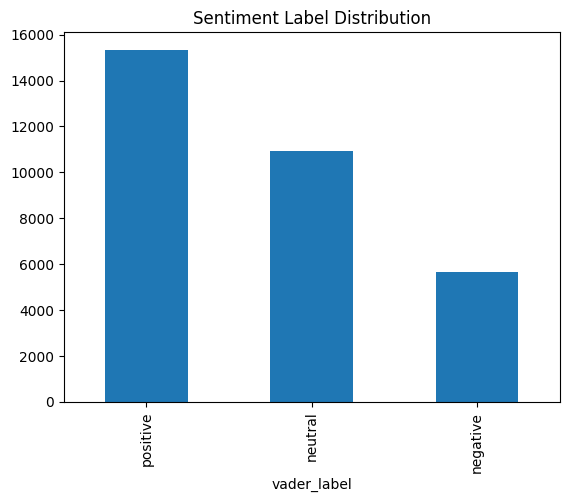

In [60]:
df2_short["vader_label"].value_counts().plot(kind='bar', title='Sentiment Label Distribution')

In [61]:
for label in ["positive", "neutral", "negative"]:
    print(f"\n--- {label.upper()} EXAMPLES ---")
    for text in df2_short[df2_short["vader_label"] == label]["text"].sample(5).to_list():
        print(text)
        print("-" * 80)


--- POSITIVE EXAMPLES ---
playlist of that sounds like taylor swift
--------------------------------------------------------------------------------
‘now taking applications’: single guys snapped up taylor swift tickets to score dates
--------------------------------------------------------------------------------
create your own lana del rey album title. mine is - discovering freedom at the white house
--------------------------------------------------------------------------------
how to write a song like ocean eyes by billie eilish (using hit songwri...
--------------------------------------------------------------------------------
meet and greet? i recently fell in love with tate but she had me since ‘you broke me first’ do you guys know about any meet and greets?
--------------------------------------------------------------------------------

--- NEUTRAL EXAMPLES ---
assuming this is about boygenius, thoughts?
--------------------------------------------------------------------

In [ ]:
# vader didnt perform wasnt super accuarte we will try bert model for sentiment analysis
from transformers import pipeline, AutoTokenizer

In [63]:
tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer=tokenizer,
)

def safe_sentiment(text):
    try:
        return sentiment_pipeline(text, truncation=True, max_length=512)[0]["label"]
    except Exception as e:
        print(f"Error: {e}")
        return "ERROR"

df2_short["bert_sentiment"] = df2_short["text"].apply(safe_sentiment)

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Exception ignored in: <function

<Axes: title={'center': 'BERT Sentiment Label Distribution'}, xlabel='bert_sentiment'>

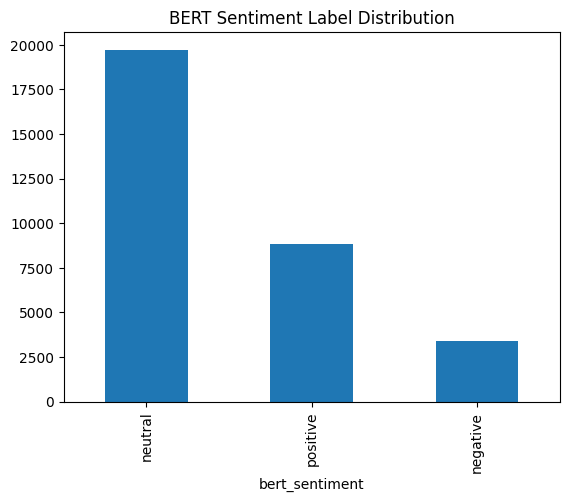

In [64]:
df2_short["bert_sentiment"].value_counts().plot(kind='bar', title='BERT Sentiment Label Distribution')

In [93]:
for label in ["positive", "neutral", "negative"]:
    print(f"\n--- {label.upper()} EXAMPLES ---")
    for text in df2_short[df2_short["bert_sentiment"] == label]["text"].sample(10).to_list():
        print(text)
        print("-" * 80)


--- POSITIVE EXAMPLES ---
taylor swift’s ‘anti-hero’ atop hot 100 for sixth week, six holiday classics scale top 10
--------------------------------------------------------------------------------
early 2010s pop music is the fuckin best
--------------------------------------------------------------------------------
from taylor swift to beyoncé, concerts are turning into something new
--------------------------------------------------------------------------------
according to the poll, here are the results so far of which is the best ariana grande album, if you want to change that, i suggest voting right now all the time you want
--------------------------------------------------------------------------------
the best of pop (by jacobelli) this is my playlist of all the best pop songs in the world, you suggest new songs to pur on the playlist (p.s. put the playlist in some order cause its real messy in customized) (i can’t paste the link)
--------------------------------------------

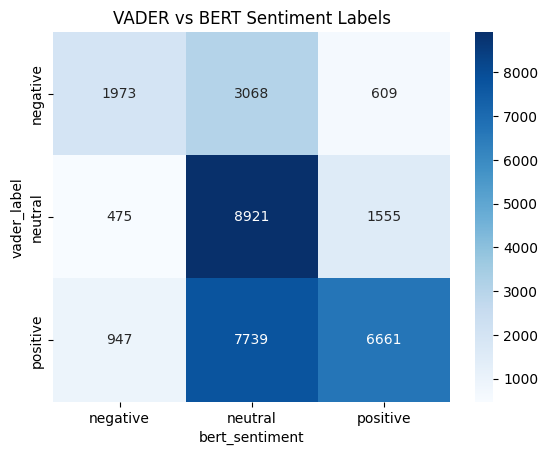

In [79]:
conf_matrix = pd.crosstab(df2_short['vader_label'], df2_short['bert_sentiment'])
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('VADER vs BERT Sentiment Labels')
plt.show()

### based on samples we can say bert did a much better job than vader in the most part vader was more of a postive leaning where bert identifies many posts as neutral (which is common in real conversations) vader and bert disagreed on  postive/neutral vader saw lots of posts as postive while bert saw it as neutral which can be more relastic in terms of social media many posts are factual, questions, or not strongly emotional. we cant now for sure if bert got everysingel post right as we have over 30k rows but for the most part it will work to train our own model latter

In [85]:
df2_short.reset_index(drop=True, inplace=True)
df2_short

,text,sentiment,vader_label,bert_sentiment
0,pitchfork track review: taylor swift’s “actual...,-0.3818,negative,negative
1,taylor swift has regained the masters of her f...,0.2023,positive,positive
2,pitchfork review: taylor swift - the life of a...,0.2023,positive,neutral
3,taylor swift announced engagement,0.5859,positive,neutral
4,taylor swift - the fate of ophelia (official m...,0.2023,positive,neutral
...,...,...,...,...
31943,why do we feel like pop music is getting more ...,0.3825,positive,negative
31944,in korea do they call kpop just regular pop mu...,0.0000,neutral,neutral
31945,are there less hours of sunlight in america du...,0.0000,neutral,neutral
31946,if there is only one woman for every ten guys ...,0.0000,neutral,neutral


In [94]:
df2_short.rename(columns={'bert_sentiment':'label'}, inplace=True)
df2_short.drop(columns=['sentiment','vader_label'],inplace=True)
df2_short

,text,label
0,pitchfork track review: taylor swift’s “actual...,negative
1,taylor swift has regained the masters of her f...,positive
2,pitchfork review: taylor swift - the life of a...,neutral
3,taylor swift announced engagement,neutral
4,taylor swift - the fate of ophelia (official m...,neutral
...,...,...
31943,why do we feel like pop music is getting more ...,negative
31944,in korea do they call kpop just regular pop mu...,neutral
31945,are there less hours of sunlight in america du...,neutral
31946,if there is only one woman for every ten guys ...,neutral


In [95]:
df2_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31948 entries, 0 to 31947
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    31948 non-null  object
 1   label   31948 non-null  object
dtypes: object(2)
memory usage: 499.3+ KB


In [96]:
df2_short.to_csv(r'C:\Users\alyah\VC\first_project\data\reddit_artist_posts_sentiment.csv', index=False)

## we now have our final df with text column and lable column using bert (pseudo-labels) now we will use this to make our own model and train it 